In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import xgboost as xgb

In [82]:
data=pd.read_csv("/content/salespricepred.csv")
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


Data Interpretation

In [83]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [84]:
data.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [85]:
data.duplicated().sum()

np.int64(0)

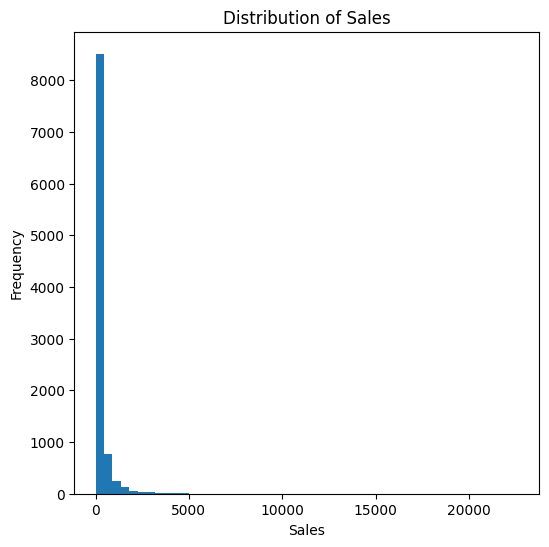

In [86]:
plt.figure(figsize=(6,6))
plt.hist(data['Sales'],bins=50)
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.title('Distribution of Sales')
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

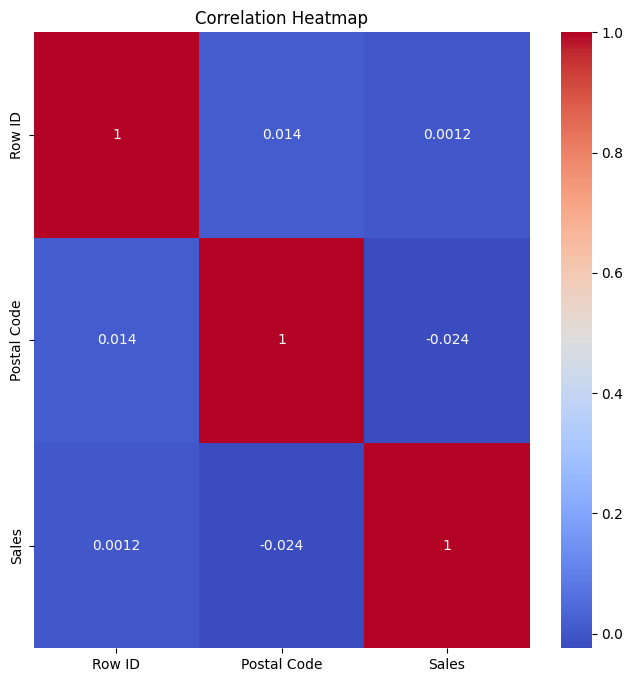

In [87]:
plt.figure(figsize=(8,8))
sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title('Correlation Heatmap')

In [88]:
for col in data.select_dtypes(include='object').columns:
  print(f"Column '{col}': {data[col].nunique()} unique values")

Column 'Order ID': 4922 unique values
Column 'Order Date': 1230 unique values
Column 'Ship Date': 1326 unique values
Column 'Ship Mode': 4 unique values
Column 'Customer ID': 793 unique values
Column 'Customer Name': 793 unique values
Column 'Segment': 3 unique values
Column 'Country': 1 unique values
Column 'City': 529 unique values
Column 'State': 49 unique values
Column 'Region': 4 unique values
Column 'Product ID': 1861 unique values
Column 'Category': 3 unique values
Column 'Sub-Category': 17 unique values
Column 'Product Name': 1849 unique values


Time Series Visualization

In [89]:
data["Order Date"] = pd.to_datetime(data["Order Date"], dayfirst=True)
data["Ship Date"] = pd.to_datetime(data["Ship Date"], dayfirst=True)

In [90]:
data.iloc[4]

,4
Row ID,5
Order ID,US-2016-108966
Order Date,2016-10-11 00:00:00
Ship Date,2016-10-18 00:00:00
Ship Mode,Standard Class
Customer ID,SO-20335
Customer Name,Sean O'Donnell
Segment,Consumer
Country,United States
City,Fort Lauderdale


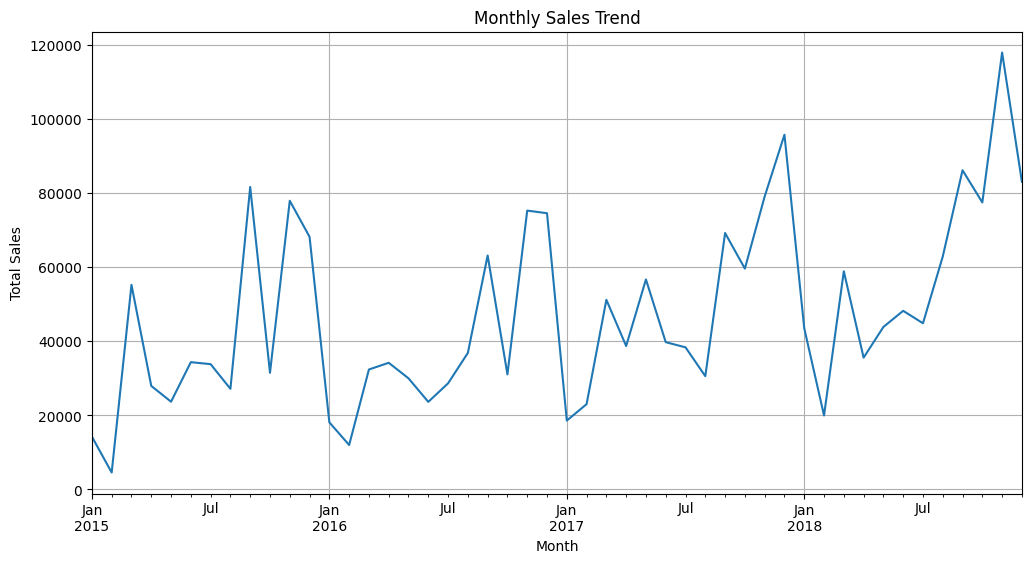

In [91]:
monthly_sales=data.groupby(data["Order Date"].dt.to_period("M"))['Sales'].sum()
plt.figure(figsize=(12,6))
monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

dt.year is for aggregating by the numerical year.
dt.to_period("M") is for aggregating by a specific month (which includes the year information), creating a time-aware index suitable for monthly trends.

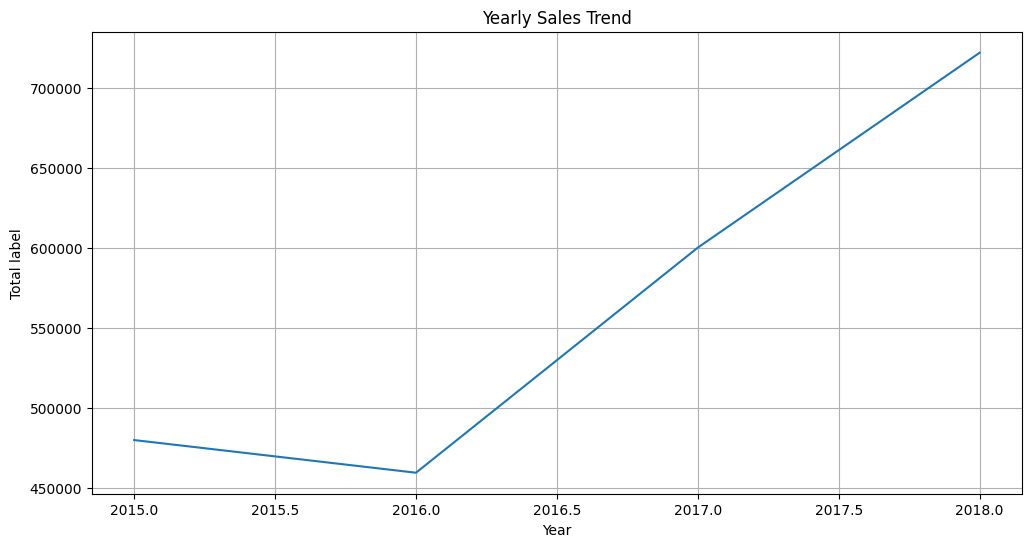

In [92]:
yearly_sales=data.groupby(data["Order Date"].dt.year)["Sales"].sum()
plt.figure(figsize=(12,6))
yearly_sales.plot()
plt.title('Yearly Sales Trend')
plt.xlabel("Year")
plt.ylabel('Total label')
plt.grid(True)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

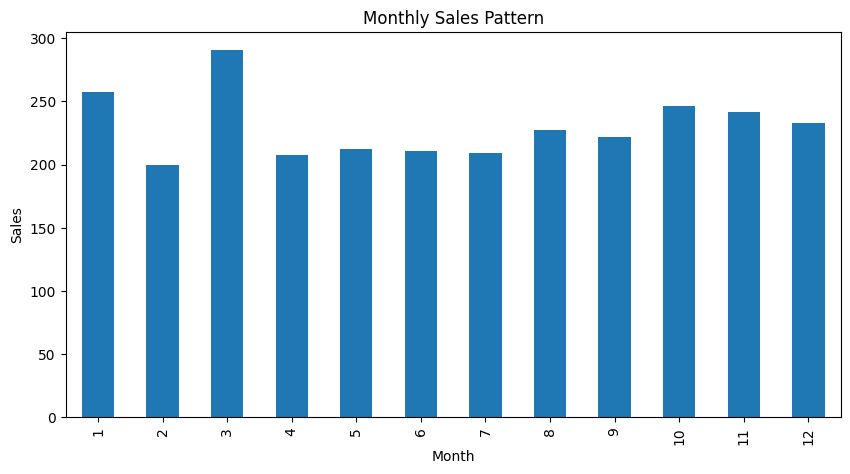

In [93]:
monthly_pattern=data.groupby(data["Order Date"].dt.month)["Sales"].mean()
plt.figure(figsize=(10,5))
monthly_pattern.plot(kind='bar')

plt.title('Monthly Sales Pattern')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show

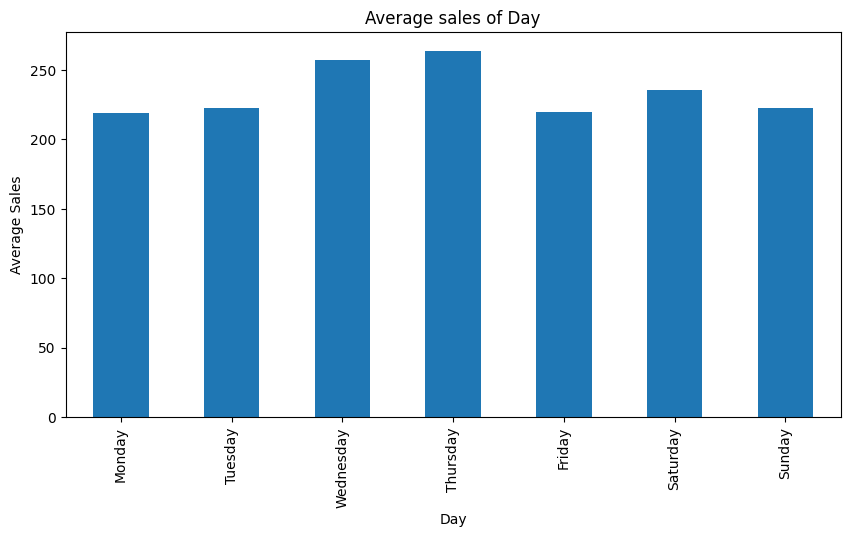

In [94]:
weekly_sales=data.groupby(data["Order Date"].dt.day_name())["Sales"].mean()

weekday_order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekly_sales=weekly_sales.reindex(weekday_order)

plt.figure(figsize=(10,5))
weekly_sales.plot(kind='bar')
plt.title("Average sales of Day")
plt.xlabel("Day")
plt.ylabel("Average Sales")

plt.show()

Feature Engineering

In [95]:
data["year"]=data["Order Date"].dt.year
data["month"]=data["Order Date"].dt.month
data["day"]=data['Order Date'].dt.day
data["day_of_week"]=data['Order Date'].dt.dayofweek
data["quarter"]=data['Order Date'].dt.quarter

In [96]:
daily_sales=(data.groupby("Order Date").agg({
    "Sales":"sum",
    "year":"first",
    "month":"first",
    "day":"first",
    "day_of_week":"first",
    "quarter":"first"
}).reset_index()
)

In [97]:
for lag in [1,2,3,5,7,10,14,21,30]:
  daily_sales[f"lag_{lag}"]=(daily_sales["Sales"].shift(lag))

In [98]:
daily_sales.sample()

,Order Date,Sales,year,month,day,day_of_week,quarter,lag_1,lag_2,lag_3,lag_5,lag_7,lag_10,lag_14,lag_21,lag_30
336,2016-02-28,551.264,2016,2,28,6,1,1159.271,25.87,37.776,2591.1,105.844,1079.962,324.11,182.72,31.538


In [99]:
daily_sales["rolling_mean_7"]=daily_sales["Sales"].rolling(window=7).mean()
daily_sales["rolling_mean_30"]=daily_sales["Sales"].rolling(window=30).mean()
daily_sales["rolling_std_7"]=daily_sales["Sales"].rolling(window=7).std()
daily_sales["rolling_std_30"]=daily_sales["Sales"].rolling(window=30).std()

In [100]:
daily_sales.sample()

,Order Date,Sales,year,month,day,day_of_week,quarter,lag_1,lag_2,lag_3,lag_5,lag_7,lag_10,lag_14,lag_21,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30
637,2017-03-05,162.344,2017,3,5,6,1,315.45,7264.422,6285.806,243.892,57.576,16.496,837.921,132.224,858.712,2066.602571,1391.846233,3229.978641,2253.797034


In [101]:
daily_sales["Sales_log"]=np.log1p(daily_sales["Sales"])

In [102]:
daily_sales=daily_sales.dropna()

In [103]:
daily_sales.isnull().sum()

,0
Order Date,0
Sales,0
year,0
month,0
day,0
day_of_week,0
quarter,0
lag_1,0
lag_2,0
lag_3,0


In [104]:
daily_sales.sample()

,Order Date,Sales,year,month,day,day_of_week,quarter,lag_1,lag_2,lag_3,...,lag_7,lag_10,lag_14,lag_21,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,Sales_log
125,2015-06-13,14.52,2015,6,13,5,2,491.55,5463.008,2501.264,...,531.16,773.7,1325.718,91.62,394.48,1511.716,1203.905867,1937.38916,1469.591968,2.74213


In [105]:
split_index=int(len(daily_sales)*0.8)
train_data=daily_sales[:split_index]
val_data=daily_sales[split_index:]
print(train_data.shape)
print(val_data.shape)

(960, 21)
(240, 21)


In [106]:
features=[
    'year',
    'month',
    'day',
    'day_of_week',
    'quarter',
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_5',
    'lag_7',
    'lag_10',
    'lag_14',
    'lag_21',
    'lag_30',
    'rolling_mean_7',
    'rolling_mean_30',
    'rolling_std_7',
    'rolling_std_30'
]
X_train=train_data[features]
y_train=train_data['Sales_log']

X_val=val_data[features]
y_val=val_data['Sales_log']

In [107]:
X_train.shape,y_train.shape,X_val.shape,y_val.shape

((960, 18), (960,), (240, 18), (240,))

In [108]:
from xgboost import XGBRegressor

In [109]:
xgb_model=XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [110]:
xgb_model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [115]:
y_pred = xgb_model.predict(X_val)

y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_val)

mae = mean_absolute_error(y_test_actual,y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual,y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1479.4882208779904
RMSE: 2275.524313088108
R2 Score: 0.14330415725429713


In [119]:
import joblib
model_filename = 'xgboost_sales_forecast_model.joblib'
joblib.dump(xgb_model, model_filename)

print(f"Model saved successfully to {model_filename}")

Model saved successfully to xgboost_sales_forecast_model.joblib


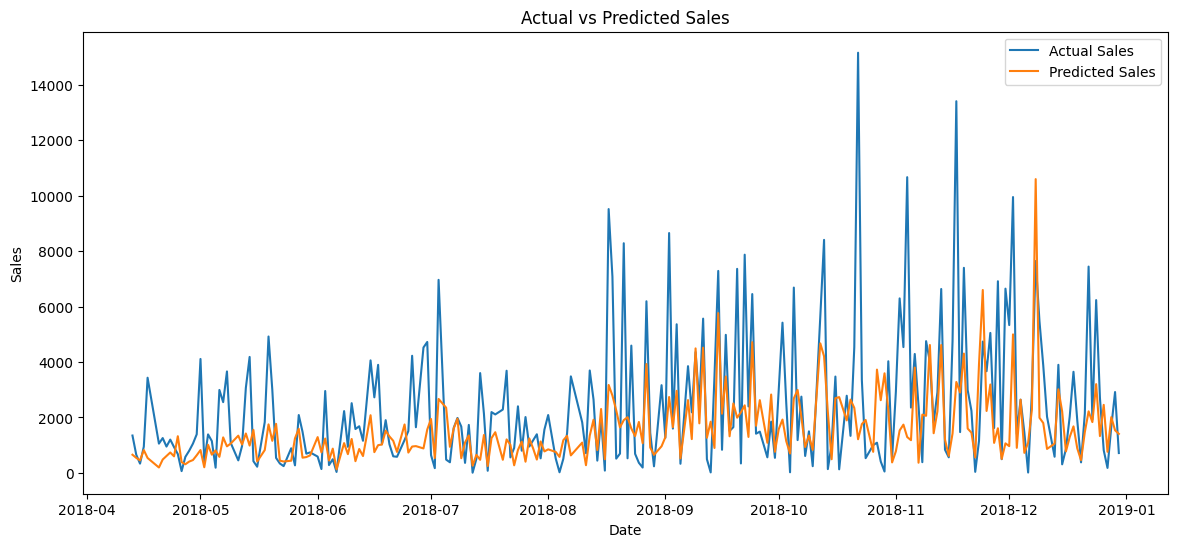

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(val_data["Order Date"],y_test_actual,label="Actual Sales")

plt.plot(val_data["Order Date"],y_pred_actual,label="Predicted Sales")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

In [118]:
feature_importances=pd.DataFrame({
    "Feature":X_train.columns,
    "Importance":xgb_model.feature_importances_
})
feature_importances=feature_importances.sort_values(by="Importance",ascending=False)
print(feature_importances)

            Feature  Importance
14   rolling_mean_7    0.169263
16    rolling_std_7    0.086195
7             lag_3    0.070015
8             lag_5    0.061594
9             lag_7    0.055771
15  rolling_mean_30    0.055015
6             lag_2    0.054230
11           lag_14    0.050594
17   rolling_std_30    0.048959
5             lag_1    0.048845
12           lag_21    0.047976
3       day_of_week    0.045520
13           lag_30    0.045481
10           lag_10    0.043503
2               day    0.036571
4           quarter    0.030802
1             month    0.028187
0              year    0.021477
